<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); padding: 40px; border-radius: 10px; margin-bottom: 20px;">
<h1 style="color: white; margin: 0; font-size: 2.5em;">Lecture 11: Testing</h1>
<p style="color: #888; font-size: 1.2em; margin-top: 10px;">Part III: Systems Integration — SCE Futures</p>
</div>

## Contents

- [Learning Objectives](#learning-objectives)

**Part 1: Test Methodology**
1. [Test Environment](#1-test-environment)
2. [DC Characterization](#2-dc-characterization)
3. [Margin Testing](#3-margin-testing)
4. [Functional Testing](#4-functional-testing)
5. [Speed and Timing](#5-speed-timing)
6. [On-Chip Test Structures](#6-test-structures)
7. [Common Failure Modes](#7-failure-modes)
8. [Debug Strategies](#8-debug-strategies)
9. [Yield and Statistics](#9-yield-statistics)

18. [Equipment and Vendor Guide](#18-equipment-vendors)
    - Automated SCE Test Systems (OCTOPUX, ICE-T)

**Infrastructure (see other lectures):**
- Cryogenic Systems → Lecture 12
- Packaging & I/O → Lecture 7

---
<a id="learning-objectives"></a>
## Learning Objectives

By the end of this session, you will be able to:

**Part 1: Test Methodology**
- Set up and operate a cryogenic test environment
- Perform DC characterization of Josephson junctions
- Measure and interpret operating margins
- Design effective on-chip test structures
- Diagnose common failure modes in SCE circuits
- Apply systematic debug strategies
- Understand yield metrics and statistical analysis

**Part 2: Test Equipment Construction**
- Design and build an LHe dip probe
- Configure a rackmount cryocooler test system
- Calculate and manage thermal budgets
- Implement proper signal integrity (coax selection, filtering)
- Design star-ground systems and avoid ground loops
- Construct multi-layer magnetic shielding
- Wire a complete cryogenic test system

---

In [1]:
# Setup
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyBboxPatch, Circle, Rectangle
import numpy as np

COLORS = {
    'primary': '#2196F3',
    'secondary': '#FF9800',
    'success': '#4CAF50',
    'danger': '#f44336',
    'warning': '#FFC107',
    'dark': '#1a1a2e',
    'light': '#f5f5f5',
    'aqfp': '#00BCD4',
    'rsfq': '#9C27B0'
}

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['font.size'] = 11

# Physical constants
Phi_0 = 2.067833848e-15  # Wb
k_B = 1.380649e-23       # J/K

print("Setup complete.")

Setup complete.


---
<a id="1-test-environment"></a>
# 1. Test Environment
---

Testing superconducting circuits requires specialized cryogenic infrastructure.

### Cryogenic Systems

| System | Base Temp | Hold Time | Use Case |
|--------|-----------|-----------|----------|
| **LHe Dewar (dip probe)** | 4.2 K | Hours | Quick characterization |
| **Closed-cycle cryocooler** | 3-4 K | Continuous | Production testing |
| **Dilution refrigerator** | 10-20 mK | Continuous | Quantum circuits |
| **ADR (Adiabatic Demag)** | <100 mK | Hours | Low-T characterization |

For AQFP and RSFQ testing, **4.2 K systems** (liquid helium or cryocoolers) are standard.

### Test Setup Block Diagram

```
    Room Temperature                      4.2 K
    ───────────────────────────────────────────────────────
    
    ┌─────────────┐     Coax/Flex      ┌─────────────────┐
    │   Pattern   │─────────────────►  │                 │
    │  Generator  │                    │   Magnetic      │
    └─────────────┘                    │   Shielding     │
                                       │  ┌───────────┐  │
    ┌─────────────┐     Filtered       │  │           │  │
    │    Bias     │─────────────────►  │  │    DUT    │  │
    │   Sources   │     lines          │  │   (Chip)  │  │
    └─────────────┘                    │  │           │  │
                                       │  └───────────┘  │
    ┌─────────────┐                    │        │        │
    │   Readout   │◄─────────────────  │        ▼        │
    │   (Scope/   │     Output         │   Cryo Amps     │
    │   Counter)  │     lines          │   (optional)    │
    └─────────────┘                    └─────────────────┘
```

### Wiring Considerations

| Wire Type | Thermal Load | Bandwidth | Use |
|-----------|--------------|-----------|-----|
| **Stainless coax** | Low | DC-1 GHz | Bias, slow signals |
| **NbTi coax** | Very low | DC-10 GHz | SC below 4K, moderate BW |
| **CuNi coax** | Medium | DC-20 GHz | High-speed I/O |
| **Phosphor bronze twisted pair** | Low | DC-1 MHz | DC bias |

### Thermal Budget

Every wire conducts heat. A 4K cryocooler typically provides:
- **1st stage (40-50 K)**: 30-50 W
- **2nd stage (4 K)**: 1-2 W

Heat loads to manage:
- Wiring: ~1-10 mW per coax
- Radiation: Minimized by shielding
- Chip dissipation: µW to mW (depends on circuit)

---
<a id="2-dc-characterization"></a>
# 2. DC Characterization
---

DC measurements verify that Josephson junctions and basic circuit elements are functional.

### Junction I-V Curve

The most fundamental measurement is the current-voltage characteristic:

```
              I
              ▲
              │           ╱
              │          ╱  ← Normal state (slope = 1/R_n)
         I_c ─┼─────────●
              │         │
              │         │  ← Supercurrent branch (V = 0)
              │         │
  ────────────┼─────────┼────────► V
              │         │
              │         │
        -I_c ─┼─────────●
             ╱
            ╱  ← Normal state (third quadrant)
```

**Key parameters extracted:**

| Parameter | Symbol | Typical Value | What It Tells You |
|-----------|--------|---------------|-------------------|
| Critical current | I_c | 50-500 µA | Junction size, quality |
| Normal resistance | R_n | 1-20 Ω | Barrier quality |
| I_c × R_n product | - | 1-2 mV | Material quality figure of merit |
| Subgap resistance | R_sg | >10 × R_n | Junction quality |
| Gap voltage | V_g | 2.8 mV (Nb) | 2Δ/e, superconductor gap |

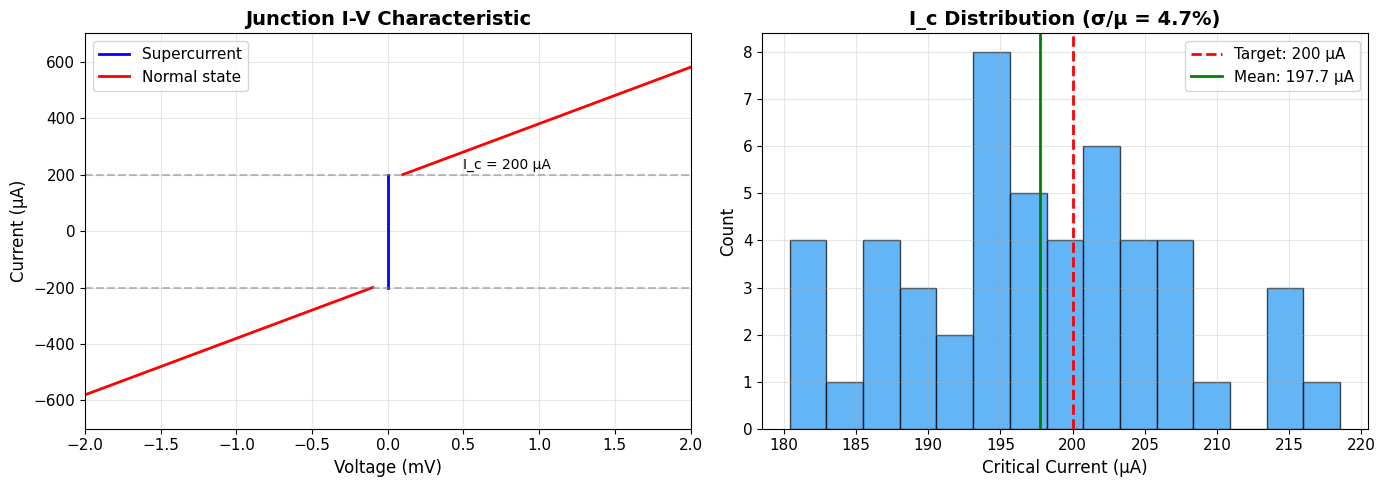

I_c × R_n = 1.00 mV (target: 1-2 mV for Nb/AlOx/Nb)


In [2]:
# Simulate and plot a JJ I-V curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Ideal I-V curve
I_c = 200e-6  # 200 µA
R_n = 5       # 5 Ω
V_g = 2.8e-3  # 2.8 mV gap voltage

# Supercurrent branch
I_super = np.linspace(-I_c, I_c, 100)
V_super = np.zeros_like(I_super)

# Normal branch (simplified RSJ model)
I_normal_pos = np.linspace(I_c, 3*I_c, 100)
V_normal_pos = (I_normal_pos - I_c) * R_n + 0.1e-3  # Small offset for visibility

I_normal_neg = np.linspace(-3*I_c, -I_c, 100)
V_normal_neg = (I_normal_neg + I_c) * R_n - 0.1e-3

ax1.plot(V_super*1e3, I_super*1e6, 'b-', linewidth=2, label='Supercurrent')
ax1.plot(V_normal_pos*1e3, I_normal_pos*1e6, 'r-', linewidth=2, label='Normal state')
ax1.plot(V_normal_neg*1e3, I_normal_neg*1e6, 'r-', linewidth=2)

ax1.axhline(I_c*1e6, color='gray', linestyle='--', alpha=0.5)
ax1.axhline(-I_c*1e6, color='gray', linestyle='--', alpha=0.5)
ax1.text(0.5, I_c*1e6 + 20, f'I_c = {I_c*1e6:.0f} µA', fontsize=10)

ax1.set_xlabel('Voltage (mV)', fontsize=12)
ax1.set_ylabel('Current (µA)', fontsize=12)
ax1.set_title('Junction I-V Characteristic', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.set_xlim(-2, 2)
ax1.set_ylim(-700, 700)

# Right: I_c variation across wafer (simulated)
np.random.seed(42)
n_junctions = 50
I_c_measured = I_c * (1 + 0.05 * np.random.randn(n_junctions))  # 5% variation

ax2.hist(I_c_measured*1e6, bins=15, color=COLORS['primary'], edgecolor='black', alpha=0.7)
ax2.axvline(I_c*1e6, color='red', linestyle='--', linewidth=2, label=f'Target: {I_c*1e6:.0f} µA')
ax2.axvline(np.mean(I_c_measured)*1e6, color='green', linestyle='-', linewidth=2, 
            label=f'Mean: {np.mean(I_c_measured)*1e6:.1f} µA')

ax2.set_xlabel('Critical Current (µA)', fontsize=12)
ax2.set_ylabel('Count', fontsize=12)
ax2.set_title(f'I_c Distribution (σ/μ = {np.std(I_c_measured)/np.mean(I_c_measured)*100:.1f}%)', 
              fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"I_c × R_n = {I_c * R_n * 1e3:.2f} mV (target: 1-2 mV for Nb/AlOx/Nb)")

### DC Test Structures

Include these on every chip for process monitoring:

| Structure | Purpose | Measurement |
|-----------|---------|-------------|
| **Single JJ** | I_c, R_n extraction | I-V curve |
| **JJ array (series)** | I_c uniformity | I-V shows weakest junction |
| **Sheet resistance** | Verify metal layers | 4-point probe |
| **Contact resistance** | Via/contact quality | Kelvin structure |
| **Inductance test** | L/square verification | SQUID or resonance |

### Measurement Best Practices

1. **Use 4-wire sensing** — Eliminates lead resistance errors
2. **Current bias, not voltage bias** — JJs are current-controlled devices
3. **Filter inputs** — Prevent noise-induced switching
4. **Ramp slowly** — Avoid transient heating
5. **Multiple sweeps** — Check for hysteresis and repeatability

---
<a id="3-margin-testing"></a>
# 3. Margin Testing
---

**Operating margins** quantify how robust a circuit is to parameter variations. This is the most critical metric for circuit functionality.

### What Are Margins?

Margins measure the range over which a bias parameter can vary while the circuit still operates correctly:

$$\text{Margin} = \frac{X_{max} - X_{min}}{X_{nominal}} \times 100\%$$

where X is the bias parameter (current, voltage, or excitation amplitude).

### Types of Margins

| Margin Type | Typical Target | What It Tests |
|-------------|----------------|---------------|
| **Bias current** | ±15-25% | DC operating point |
| **Excitation amplitude** (AQFP) | ±20-25% | Clock/power delivery |
| **Clock timing** | ±10-20% of period | Setup/hold times |
| **Input amplitude** | ±15-20% | Signal integrity |
| **Temperature** | ±0.5-1 K | Thermal stability |

In [ ]:
# Visualize margin measurement
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: 1D margin plot
bias = np.linspace(0.5, 1.5, 200)
# Simulated bit error rate vs bias
ber = np.where((bias > 0.75) & (bias < 1.25), 0, 
               np.exp(-50*(np.minimum(np.abs(bias-0.75), np.abs(bias-1.25)))))

ax1.semilogy(bias, ber + 1e-12, 'b-', linewidth=2, label='BER vs bias')

# Shade the operating region (between margin boundaries)
ax1.axvspan(0.75, 1.25, alpha=0.15, color='green', label='Operating region')

# Margin boundaries
ax1.axvline(0.75, color='red', linestyle='--', linewidth=2)
ax1.axvline(1.25, color='red', linestyle='--', linewidth=2)
ax1.axvline(1.0, color='green', linestyle='-', linewidth=2, label='Nominal')

# BER threshold line
ax1.axhline(1e-9, color='orange', linestyle=':', linewidth=2, alpha=0.8)
ax1.text(1.42, 2e-9, 'BER threshold\n(10⁻⁹)', fontsize=9, color='orange', va='bottom')

# Margin annotation
ax1.annotate('', xy=(0.75, 1e-6), xytext=(1.25, 1e-6),
             arrowprops=dict(arrowstyle='<->', color='red', lw=2))
ax1.text(1.0, 3e-6, '±25% margin', ha='center', fontsize=11, color='red', fontweight='bold')

ax1.set_xlabel('Normalized Bias', fontsize=12)
ax1.set_ylabel('Bit Error Rate', fontsize=12)
ax1.set_title('1D Margin Measurement', fontsize=14, fontweight='bold')
ax1.set_ylim(1e-12, 1)
ax1.set_xlim(0.5, 1.5)
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Right: 2D margin map (shmoo plot)
x = np.linspace(0.6, 1.4, 50)
y = np.linspace(0.6, 1.4, 50)
X, Y = np.meshgrid(x, y)

# Operating region is roughly elliptical
Z = ((X - 1.0)**2 / 0.2**2 + (Y - 1.0)**2 / 0.22**2) < 1

ax2.contourf(X, Y, Z.astype(float), levels=[0.5, 1.5], colors=[COLORS['success']], alpha=0.5)
ax2.contour(X, Y, Z.astype(float), levels=[0.5], colors=['green'], linewidths=2)
ax2.plot(1.0, 1.0, 'k*', markersize=15, label='Nominal')

# Draw margin box
rect = plt.Rectangle((0.8, 0.78), 0.4, 0.44, fill=False, edgecolor='red', 
                       linestyle='--', linewidth=2, label='±20% margins')
ax2.add_patch(rect)

ax2.set_xlabel('Bias 1 (normalized)', fontsize=12)
ax2.set_ylabel('Bias 2 (normalized)', fontsize=12)
ax2.set_title('2D Margin Map (Shmoo Plot)', fontsize=14, fontweight='bold')
ax2.set_aspect('equal')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Left: BER drops to unmeasurable levels within the operating region.")
print("      Circuit passes when BER < threshold (e.g., 10⁻⁹) across the full margin range.")
print("Right: Green = pass, white = fail. Goal: green region contains the ±20% box.")

### Margin Measurement Procedure

**1D Margin Sweep:**
1. Set all biases to nominal
2. Apply test pattern (e.g., PRBS, walking ones)
3. Sweep one bias from low to high
4. Record pass/fail at each point
5. Find lower and upper boundaries
6. Repeat for each bias

**2D Margin Map (Shmoo Plot):**

A **shmoo plot** is a 2D pass/fail map showing how a circuit behaves across two swept parameters. The name comes from Al Capp's 1940s cartoon character whose blob-like shape resembles typical pass regions. It's standard terminology in semiconductor testing.

1. Choose two critical biases
2. Sweep both in a grid pattern
3. Record pass/fail at each (x, y) point
4. Visualize as a 2D map (green = pass, white = fail)
5. Reveals correlations between parameters

### Interpreting Shmoo Plots

| Pattern | Interpretation | Action |
|---------|---------------|--------|
| Large, centered region | Good design | Ship it |
| Small region | Marginal design | Redesign or screen |
| Off-center region | Nominal values wrong | Re-target biases |
| Irregular shape | Multiple failure modes | Investigate edges |
| Holes in region | Intermittent failures | Check for noise, flux |

---
<a id="4-functional-testing"></a>
# 4. Functional Testing
---

Functional testing verifies that the circuit performs its intended logic operation.

### Test Pattern Types

| Pattern | Purpose | Coverage |
|---------|---------|----------|
| **Exhaustive** | All input combinations | 100% (small circuits only) |
| **Walking ones/zeros** | Stuck-at faults | Basic connectivity |
| **PRBS** | Random patterns | Statistical coverage |
| **ATPG** (Auto Test Pattern Gen) | Targeted fault coverage | Specific faults |
| **Functional vectors** | Real use cases | Application-specific |

### Test Architecture

For complex circuits, build in test infrastructure with shift registers at I/O:

```mermaid
flowchart LR
    subgraph chip[Chip]
        direction TB
        IN[Input<br/>Shift Reg] --> CUT[Circuit<br/>Under Test]
        CUT --> OUT[Output<br/>Shift Reg]
    end
    
    TI[Test<br/>Input] --> IN
    OUT --> TO[Test<br/>Output]

    style CUT fill:#E3F2FD,stroke:#1976D2,stroke-width:2px
    style IN fill:#C8E6C9
    style OUT fill:#C8E6C9
```

Shift registers allow serial loading/unloading of test vectors, reducing pin count.

### Scan Chain Architecture

In CMOS, **scan chains** insert a mux at each flip-flop to enable shift-register mode:

```
  scan_enable ─────────────────────────────────┐
                                               │
  Serial In ──► [MUX→DFF] ──► [MUX→DFF] ──► [MUX→DFF] ──► Serial Out
                  │              │              │
                  ▼              ▼              ▼
             Circuit Node   Circuit Node   Circuit Node
```

Each scan cell:
- `scan_enable = 0`: MUX passes functional data — chip runs normally
- `scan_enable = 1`: MUX passes scan data — shift register mode for test vectors

**AQFP Considerations:**

| Aspect | CMOS | AQFP |
|--------|------|------|
| Scan mux cost | ~2 transistors | Full MAJ gate per cell |
| Clock overhead | Minimal | Extra phases for mux + DFF |
| Shift register | Standard | Chain of clocked buffers (straightforward) |
| scan_enable routing | Simple wire | Must distribute to all cells |

The overhead in AQFP is significant: a mux at every scan point plus global scan_enable routing. For large designs, consider scan only at block boundaries rather than every flip-flop.

### Speed Considerations

| Test Mode | Speed | Purpose |
|-----------|-------|--------|
| **Low-speed scan** | kHz-MHz | Debug, pattern loading |
| **At-speed functional** | GHz | Verify timing margins |
| **Overdrive** | >nominal | Stress testing |

### Pass/Fail Criteria

- **Bit Error Rate (BER)**: Typically require BER < 10⁻¹² for production
- **Pattern match**: All output bits match expected values
- **Timing**: Outputs arrive within specified window

---
<a id="5-speed-timing"></a>
# 5. Speed and Timing
---

### Maximum Frequency Testing

To find the maximum operating frequency:

1. Start at a known-good low frequency
2. Run functional test pattern
3. Increment frequency
4. Repeat until errors appear
5. Back off to find reliable maximum

### Timing Measurements

| Measurement | Method | Precision |
|-------------|--------|----------|
| **Propagation delay** | Input-to-output time | ~10 ps |
| **Setup time** | Clock-to-data timing | ~10 ps |
| **Hold time** | Data-to-clock timing | ~10 ps |
| **Jitter** | Edge-to-edge variation | ~1 ps RMS |

### AQFP Timing Characteristics

In AQFP, timing is determined by the **external AC excitation**:

- **Clock frequency** = excitation frequency (typically 5-10 GHz)
- **Stage delay** = 1/4 clock period (one phase step)
- **Pipeline latency** = N stages × stage delay

Timing extraction approach:
1. Measure output vs. excitation phase relationship
2. Sweep excitation frequency to find margins
3. Characterize setup/hold by shifting input timing relative to excitation

### Frequency Margin Testing

```
    Error Rate
         │
    10⁰  │▓▓▓                              ▓▓▓
         │  ▓▓                            ▓▓
    10⁻⁶ │    ▓▓                        ▓▓
         │      ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
    10⁻¹²│        │                    │
         └────────┼────────────────────┼────► Frequency
                f_min              f_max
                  
                  ◄─── Operating Range ───►
```

The operating frequency range reveals timing margins in the design.

---
<a id="6-test-structures"></a>
# 6. On-Chip Test Structures
---

Every chip should include **Process Control Monitors (PCMs)** to diagnose issues.

### Essential Test Structures

| Structure | What It Measures | Failure Indication |
|-----------|------------------|-------------------|
| **Single JJ (multiple sizes)** | I_c, R_n vs. area | Process variation |
| **JJ chain (series)** | I_c uniformity | Weak junction in chain |
| **Sheet R (each metal)** | Layer resistance | Deposition issues |
| **Via chain** | Contact resistance | Etch/clean problems |
| **Inductor (known L)** | Inductance | Layer thickness |
| **SQUID magnetometer** | Ambient field | Shielding verification |
| **Margin monitor** | Single gate margins | Process centering |
| **Buffer chain** | Stage delay, signal integrity | Timing verification |

### Test Structure Placement

PCMs are typically placed wherever space permits — often in gaps between bond pads or in unused corners. There's no single standard; placement depends on available area and what you need to monitor.

### SQUID-Based Field Monitor

A simple DC SQUID can verify your magnetic shielding:

- Measure I_c modulation vs. applied field
- Offset from expected curve indicates ambient field at the chip
- Useful for confirming shielding is working before cooldown through T_c

**Note:** SQUIDs measure ambient field, not trapped flux. Trapped flux in the circuit itself must be inferred from circuit behavior (margin shifts, cooldown-dependent failures).

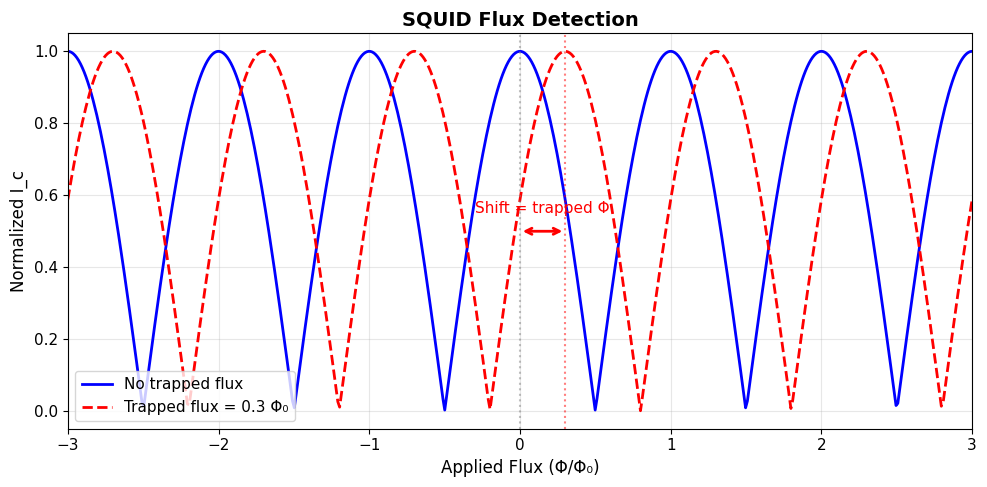

The shift in the SQUID modulation curve reveals trapped flux.
Multiple SQUIDs across the chip can map the flux distribution.


In [4]:
# Visualize SQUID flux detection
fig, ax = plt.subplots(figsize=(10, 5))

# SQUID I_c vs flux
phi = np.linspace(-3, 3, 500)  # flux in units of Φ₀
I_c_squid = np.abs(np.cos(np.pi * phi))  # Idealized SQUID modulation

# Without trapped flux (centered)
ax.plot(phi, I_c_squid, 'b-', linewidth=2, label='No trapped flux')

# With trapped flux (shifted)
phi_trapped = 0.3  # 0.3 Φ₀ trapped
ax.plot(phi, np.abs(np.cos(np.pi * (phi - phi_trapped))), 'r--', linewidth=2, 
        label=f'Trapped flux = {phi_trapped} Φ₀')

ax.axvline(0, color='gray', linestyle=':', alpha=0.5)
ax.axvline(phi_trapped, color='red', linestyle=':', alpha=0.5)

ax.annotate('', xy=(phi_trapped, 0.5), xytext=(0, 0.5),
            arrowprops=dict(arrowstyle='<->', color='red', lw=2))
ax.text(phi_trapped/2, 0.55, 'Shift = trapped Φ', ha='center', fontsize=11, color='red')

ax.set_xlabel('Applied Flux (Φ/Φ₀)', fontsize=12)
ax.set_ylabel('Normalized I_c', fontsize=12)
ax.set_title('SQUID Flux Detection', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(-3, 3)

plt.tight_layout()
plt.show()

print("The shift in the SQUID modulation curve reveals trapped flux.")
print("Multiple SQUIDs across the chip can map the flux distribution.")

---
<a id="7-failure-modes"></a>
# 7. Common Failure Modes
---

Understanding failure modes helps focus debug efforts.

### Fabrication-Related Failures

These are typically caught by the fab's process control monitors before chips ship. Included here for completeness, but circuit designers rarely see these directly.

| Failure | Symptom | Root Cause |
|---------|---------|------------|
| **Open junction** | No I_c, high R | Barrier too thick, lithography |
| **Shorted junction** | No R_n, low R | Barrier pinholes, particles |
| **I_c too low** | Reduced margins | Barrier thick, oxidation |
| **I_c too high** | Reduced margins, excess power | Barrier thin |
| **Open via** | No connectivity | Etch residue, undercut |
| **Metal short** | Unintended connection | Particles, lithography |
| **Metal open** | No connectivity | Over-etch, particles |

### Design-Related Failures

| Failure | Symptom | Root Cause |
|---------|---------|------------|
| **Path imbalance** | Wrong output values | Unequal delays to gate |
| **Insufficient margin** | Intermittent errors | Undersized JJs or L |
| **Crosstalk** | Pattern-dependent errors | Inadequate spacing |
| **Missing splitter** | Fan-out failure | Forgot fan-out > 1 |
| **Wrong polarity** | Inverted logic | Transformer winding error |

### Environment-Related Failures

| Failure | Symptom | Root Cause |
|---------|---------|------------|
| **Flux trapping** | Random errors per cooldown | Ambient field, shielding |
| **Temperature drift** | Margin variation | Cryostat instability |
| **EMI pickup** | Burst errors | Inadequate filtering |
| **Ground loops** | Offset, noise | Wiring topology |

---
<a id="8-debug-strategies"></a>
# 8. Debug Strategies
---

Systematic debug is essential when circuits fail.

### Debug Flowchart

```
    Circuit fails
         │
         ▼
    ┌─────────────┐     No      ┌─────────────────┐
    │ PCMs pass?  │────────────►│ Fabrication     │
    └──────┬──────┘             │ issue - check   │
           │ Yes                │ wafer lot       │
           ▼                    └─────────────────┘
    ┌─────────────┐     No      ┌─────────────────┐
    │ DC biases   │────────────►│ Setup issue -   │
    │ correct?    │             │ check wiring    │
    └──────┬──────┘             └─────────────────┘
           │ Yes
           ▼
    ┌─────────────┐     No      ┌─────────────────┐
    │ Margins     │────────────►│ Marginal design │
    │ centered?   │             │ or process edge │
    └──────┬──────┘             └─────────────────┘
           │ Yes
           ▼
    ┌─────────────┐     No      ┌─────────────────┐
    │ Repeatable  │────────────►│ Flux trapping   │
    │ across      │             │ or intermittent │
    │ cooldowns?  │             │ connection      │
    └──────┬──────┘             └─────────────────┘
           │ Yes
           ▼
    ┌─────────────────────────────────────────────┐
    │ Pattern-dependent failure - check design   │
    │ (path balance, fan-out, polarity)          │
    └─────────────────────────────────────────────┘
```

### Isolation Techniques

1. **Binary search**: Test half the circuit, narrow down
2. **Known-good substitution**: Replace suspected block
3. **Boundary scan**: Observe internal nodes via shift registers
4. **Bias walking**: Vary one bias while monitoring output
5. **Pattern reduction**: Simplify test pattern to isolate failure

### Correlation Analysis

When failures occur:
- **Lot correlation**: Same wafer lot? → Fab issue
- **Position correlation**: Same die location? → Mask defect
- **Cooldown correlation**: Random per cooldown? → Flux trapping
- **Pattern correlation**: Same input pattern? → Design issue
- **Time correlation**: Drift over hours? → Thermal or bias drift

---
<a id="9-yield-statistics"></a>
# 9. Yield and Statistics
---

### Yield Models

Circuit yield follows the Poisson defect model:

$$Y = e^{-D \cdot N}$$

where:
- Y = yield (probability of working circuit)
- D = defect density per junction
- N = number of junctions

| Defect Density | 1,000 JJ | 10,000 JJ | 100,000 JJ | 1,000,000 JJ |
|----------------|----------|-----------|------------|---------------|
| D = 10⁻⁴ | 90% | 37% | 0.005% | ~0% |
| D = 10⁻⁵ | 99% | 90% | 37% | 0.005% |
| D = 10⁻⁶ | 99.9% | 99% | 90% | 37% |
| D = 3×10⁻⁶ (MIT LL) | 99.7% | 97% | 74% | 5% |

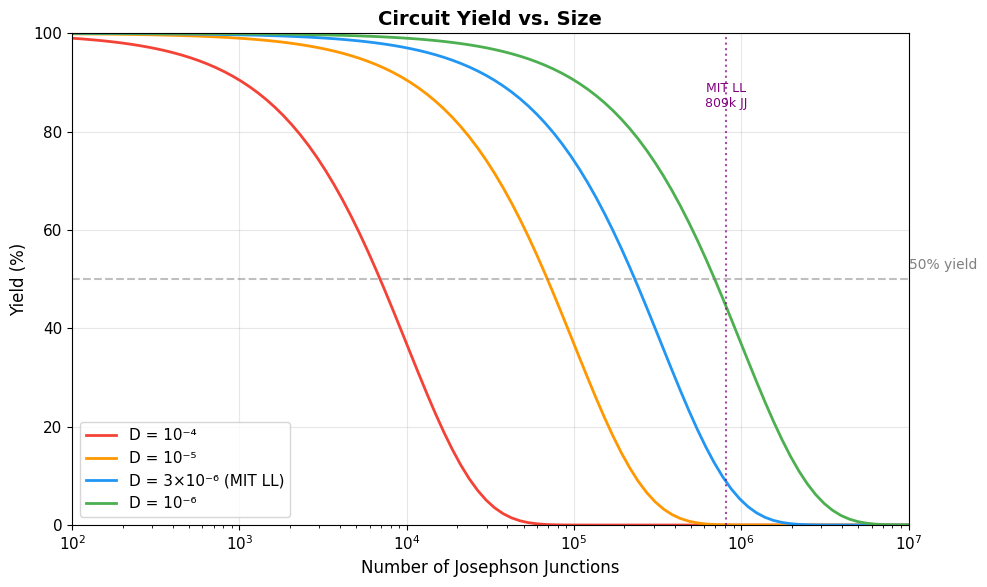

Yield improvement requires reducing defect density D.
Current state-of-the-art (MIT LL): D ≈ 3×10⁻⁶
Target for million-junction circuits: D < 10⁻⁶


In [5]:
# Yield vs circuit size for different defect densities
fig, ax = plt.subplots(figsize=(10, 6))

N = np.logspace(2, 7, 100)  # 100 to 10M junctions
defect_densities = [1e-4, 1e-5, 3e-6, 1e-6]
colors = [COLORS['danger'], COLORS['secondary'], COLORS['primary'], COLORS['success']]
labels = ['D = 10⁻⁴', 'D = 10⁻⁵', 'D = 3×10⁻⁶ (MIT LL)', 'D = 10⁻⁶']

for D, color, label in zip(defect_densities, colors, labels):
    Y = np.exp(-D * N) * 100
    ax.semilogx(N, Y, color=color, linewidth=2, label=label)

ax.axhline(50, color='gray', linestyle='--', alpha=0.5)
ax.text(1e7, 52, '50% yield', fontsize=10, color='gray')

# Mark MIT LL 809k demonstration
ax.axvline(809120, color='purple', linestyle=':', alpha=0.7)
ax.text(809120, 85, 'MIT LL\n809k JJ', ha='center', fontsize=9, color='purple')

ax.set_xlabel('Number of Josephson Junctions', fontsize=12)
ax.set_ylabel('Yield (%)', fontsize=12)
ax.set_title('Circuit Yield vs. Size', fontsize=14, fontweight='bold')
ax.legend(loc='lower left')
ax.grid(True, alpha=0.3)
ax.set_xlim(100, 1e7)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

print("Yield improvement requires reducing defect density D.")
print("Current state-of-the-art (MIT LL): D ≈ 3×10⁻⁶")
print("Target for million-junction circuits: D < 10⁻⁶")

### Statistical Sampling

For production testing, statistical methods are essential:

| Method | Sample Size | Purpose |
|--------|-------------|--------|
| **100% test** | All | High-value parts |
| **Lot sampling** | n per lot | Process monitoring |
| **SPC (Statistical Process Control)** | Continuous | Trend detection |
| **DOE (Design of Experiments)** | Structured | Process optimization |

### Yield Learning

Track these metrics over time to drive improvement:

1. **First-pass yield**: % working on first test
2. **Final yield**: % working after debug/rework
3. **Yield by failure mode**: Which defects dominate?
4. **Yield vs. circuit size**: Extracting defect density
5. **Yield vs. wafer position**: Edge effects, gradients

---
## Summary

### Test Environment
- 4.2 K cryogenic system with magnetic shielding
- Careful thermal and signal integrity management

### Key Measurements
- **DC characterization**: I-V curves, I_c, R_n extraction
- **Margin testing**: ±20-25% operating margins target
- **Functional testing**: Pattern-based verification
- **Speed testing**: Maximum frequency, timing margins

### Test Structures
- Include PCMs on every chip: single JJ, chains, sheet R, SQUIDs
- Buffer chains for timing verification
- Flux monitors for trapped flux detection

### Debug Approach
- Systematic: PCMs → biases → margins → repeatability → patterns
- Correlation analysis: lot, position, cooldown, pattern

### Yield
- Y = e^(-D×N): Defect density determines scaling limit
- Current state-of-the-art: D ≈ 3×10⁻⁶ (MIT LL)

---
<a id="18-equipment-vendors"></a>
# 18. Equipment and Vendor Guide
---

Specific recommendations for building a cryogenic SCE test system.

### Cryocoolers

| Vendor | Model | Type | 4K Power | Notes |
|--------|-------|------|----------|-------|
| **Sumitomo** | RDK-408D2 | GM | 1.5 W | Workhorse, reliable |
| **Sumitomo** | RDK-415D | GM | 1.5 W | Newer version |
| **Cryomech** | PT410 | Pulse Tube | 1.0 W | Lower vibration |
| **Cryomech** | PT415 | Pulse Tube | 1.5 W | Higher capacity PT |
| **Sumitomo** | RP-082B2 | Pulse Tube | 0.9 W | Compact PT |
| **Bluefors** | SD series | Dilution | mK | For quantum work |

**Compressors**: Matched to cold head (Sumitomo CNA-11, Cryomech CP2870)

### Coaxial Cables

| Vendor | Part Number | Type | Z₀ | Notes |
|--------|-------------|------|-----|-------|
| **Micro-Coax** | UT-085-SS | Semi-rigid SS | 50Ω | Standard |
| **Micro-Coax** | UT-047-SS | Semi-rigid SS | 50Ω | Lower heat load |
| **Coax Co** | SC-086/50-SS-SS | Semi-rigid SS | 50Ω | Premium |
| **Coax Co** | SC-086/50-CN-CN | Semi-rigid CuNi | 50Ω | Moderate thermal |
| **Coax Co** | SC-086/50-NbTi-NbTi | Superconducting | 50Ω | Lowest loss below T_c |
| **Lake Shore** | Type C | Coax | 50Ω | Cryo-rated assemblies |
| **Keycom** | Various | Semi-rigid | 50Ω | Good NbTi options |

### DC Wiring

| Vendor | Type | AWG | Notes |
|--------|------|-----|-------|
| **Lake Shore** | Quad-Twist | 32-36 | Phosphor bronze, cryo-rated |
| **Lake Shore** | Cryogenic Wire | Various | Pre-spooled for cryo |
| **CMR Direct** | Manganin wire | 32-40 | Bulk spools |
| **Supercon Inc** | NbTi wire | 36+ | Superconducting |
| **California Fine Wire** | Custom | Various | Many alloys |

### Connectors

| Vendor | Series | Type | Notes |
|--------|--------|------|-------|
| **Amphenol** | SMA | RF coax | Standard, cheap |
| **Rosenberger** | SMA/2.92mm | RF coax | Higher quality |
| **Southwest Microwave** | 2.92mm/2.4mm | RF coax | Precision, expensive |
| **Samtec** | SFMC | Flex/board | Cryo-rated micro coax |
| **Hirose** | FH12/FH19 | Flex ZIF | Works at cryo (not rated) |
| **Omnetics** | Nano-D | High density DC | Mil-spec, cryo OK |
| **Glenair** | Micro-D | High density DC | Hermetic options |

### Filters

| Vendor | Type | Application | Notes |
|--------|------|-------------|-------|
| **Mini-Circuits** | LFCN/HFCN series | LP/HP coax | Cheap, work at cryo |
| **K&L Microwave** | Custom | LP/BP/HP | Higher performance |
| **Marki Microwave** | Reflectionless | LP | No reflections |
| **API Technologies** | Feedthrough caps | DC filtering | Pi-filters |
| **Spectrum Control** | EMI filters | DC feedthrough | Integrated filtering |
| **Tusonix** | Ceramic caps | Feedthrough | Simple, cheap |

### Attenuators

| Vendor | Model | Notes |
|--------|-------|-------|
| **XMA/Omni-Spectra** | Fixed SMA attenuators | Standard, work at cryo |
| **Weinschel** | Fixed/Variable | Higher precision |
| **Mini-Circuits** | VAT series | Variable |
| **Bluefors** | Cryo attenuators | Designed for dilution fridges |

### Amplifiers (Room Temperature)

| Vendor | Model | Bandwidth | Noise | Notes |
|--------|-------|-----------|-------|-------|
| **Mini-Circuits** | ZFL-500LN+ | DC-500 MHz | 2.9 dB NF | Low noise, cheap |
| **Mini-Circuits** | ZX60-P103LN+ | 0.5-10 GHz | 1.0 dB NF | Wideband |
| **RF Bay** | LNA series | Various | ~1 dB NF | Good value |
| **Pasternack** | PE15A series | Various | Various | Quick delivery |

### Amplifiers (Cryogenic)

These are all expensive ($5-20k+). For low-noise analog readout, there's no cheap alternative.

| Vendor | Model | Temp | Notes |
|--------|-------|------|-------|
| **Low Noise Factory** | LNF-LNC | 4K | State-of-the-art HEMT |
| **Cosmic Microwave Tech** | CITLF series | 4K | HEMT, good availability |
| **Caltech** | Custom HEMT | 4K | Research-grade |
| **NRAO** | Custom | 4K | Radio astronomy heritage |

**Budget alternative for digital signals:** Qorvo GaAs MMIC amplifiers (e.g., TGA series) can work at 4K for digital readout where noise figure is less critical. Not characterized for cryo, but worth trying if budget is tight.

### Magnetic Shielding

| Vendor | Material | Notes |
|--------|----------|-------|
| **Magnetic Shield Corp** | Finemet tape/cans | **Preferred** - high µ, no anneal |
| **Vacuumschmelze** | Cryoperm 10 | Cryo-rated mu-metal |
| **Amuneal** | A4K | Optimized for 4K |
| **MuShield** | Mu-metal | Requires annealing |
| **Goodfellow** | Pb foil | Lead for SC shield |
| **Alfa Aesar** | Pb sheet | Lead sheet stock |

### Thermometry

| Vendor | Type | Range | Notes |
|--------|------|-------|-------|
| **Lake Shore** | DT-670 Si Diode | 1.4-500 K | Standard, cheap |
| **Lake Shore** | Cernox CX-1050 | 0.1-420 K | Low B-field sensitivity |
| **Lake Shore** | RX-202A RuO₂ | 0.05-40 K | Best for <4K |
| **Scientific Instruments** | Si diode | 1.4-500 K | Alternative vendor |
| **Lakeshore** | Model 336/372 | Controller | Temperature readout |

### Vacuum Equipment

| Vendor | Type | Notes |
|--------|------|-------|
| **Edwards** | nXDS dry scroll | Roughing pump |
| **Pfeiffer** | HiPace turbo | Turbo pump |
| **Agilent** | TwisTorr turbo | Magnetic bearing (low field) |
| **MKS/Granville-Phillips** | Ion gauge | Pressure measurement |
| **Kurt J. Lesker** | Feedthroughs | SMA, DC, optical |
| **MDC Vacuum** | Flanges, fittings | ISO/KF/CF components |
| **Swagelok** | VCR fittings | Gas handling |

### Thermal Management

| Vendor | Product | Notes |
|--------|---------|-------|
| **Apiezon** | N grease | Demountable thermal joints |
| **Apiezon** | H grease | Higher temp range |
| **Henkel** | Stycast 2850FT | Epoxy, permanent joints |
| **CMR Direct** | GE 7031 varnish | Wire anchoring |
| **Lakeshore** | Copper braid | Flexible thermal links |
| **TAI** | OFHC Cu | Custom machined parts |

### Test Instrumentation

| Vendor | Type | Notes |
|--------|------|-------|
| **Keysight** | BERT (M8020A) | Bit error rate testing |
| **Keysight** | AWG (M8190A) | Arbitrary waveform |
| **Tektronix** | AWG5200 series | Arbitrary waveform, good value |
| **Keysight** | Scope (UXR) | High bandwidth scope |
| **Tektronix** | Scope | Alternative |
| **Stanford Research** | SR830 Lock-in | Low-level AC measurements |
| **Keithley** | 2182A | Nanovoltmeter (precision V measurement) |
| **Keithley** | 6221 | Precision current source |
| **Yokogawa** | GS200 | Precision DC source |
| **National Instruments** | DAQ | Data acquisition |



### Automated SCE Test Systems

Purpose-built systems for superconducting circuit characterization:

| System | Vendor | Features | Notes |
|--------|--------|----------|-------|
| **OCTOPUX** | RedHiTech | 32/64/128 channels, ±200µA-200mA bias, 0.5µV precision | **Industry standard** since 1997 |
| **ICE-T** | HYPRES | Cryogen-free, modular inserts, dual-insert option | Integrated cryostat + electronics |

#### OCTOPUX System

The [OCTOPUX](https://www.redhitech.com/octopux.html) is the de facto standard for automated superconducting circuit testing:

**Specifications:**
- **Channels**: 32, 64, or 128 universal I/O
- **DC bias**: 4 programmable ranges (±200 µA to ±200 mA), 16-bit resolution
- **Measurement**: Differential, 0.5 µV P-P accuracy in 4 kHz BW
- **DAQ**: Up to 2 MS/s, 10 µV P-P noise at 1 MS/s
- **Interference rejection**: Designed to minimize 50/60 Hz and RF pickup

**Key capabilities:**
- Automated I_c measurement for all junction types
- On-chip R and L extraction
- Multidimensional parametric margin analysis
- Real-time oscilloscope with spectral analysis
- MATLAB integration for custom scripts
- Self-calibration and diagnostics

**Best for**: RSFQ/ERSFQ testing, production characterization, margin mapping

**Note**: Limited for high-impedance loads (>1 kΩ) — not ideal for nanocryotron testing.

#### HYPRES ICE-T

The [ICE-T](https://www.hypres.com/products/integrated-cryogenic-electronics-test-bed-ice-t/) (Integrated Cryogenic Electronics Test-bed) combines cryostat and test electronics:

**Features:**
- Cryogen-free (closed-cycle cryocooler)
- Modular electrical inserts (standard or custom)
- Single insert (ISO-160) or dual insert (2× ISO-100) configurations
- Inserts can also work as LHe immersion probes

**Best for**: Labs wanting turnkey solution, rapid chip turnaround

#### DIY Alternative: FPGA + DAC/ADC

For custom or budget-constrained setups:

| Component | Options | Notes |
|-----------|---------|-------|
| **FPGA** | Xilinx RFSoC (ZCU111, ZCU216) | Integrated ADC/DAC |
| **DAC** | AD9164, DAC38RF | High-speed, multi-channel |
| **ADC** | AD9208, LTC2387 | High-speed sampling |
| **Bias DAC** | AD5791 (20-bit), DAC8565 | Precision DC |
| **Current source** | Custom or Keithley 6221 | Low-noise bias |

Building custom test systems requires significant software development but offers maximum flexibility for AQFP-specific requirements (e.g., 4-phase AC excitation control).

### Flex PCB Vendors

| Vendor | Notes |
|--------|-------|
| **Rigiflex** | US-based, good quality |
| **Epec** | US-based, fast turn |
| **PCBWay** | Overseas, cheap prototypes |
| **Sierra Circuits** | US, high-end |
| **Flexible Circuit Technologies** | Cryo experience |

### Other Useful Vendors

| Vendor | Products |
|--------|----------|
| **Lake Shore Cryotronics** | Full cryo catalog |
| **Janis Research** | Cryostats, probes |
| **Bluefors** | Dilution refrigerators |
| **ColdEdge Technologies** | Cryostat integration |
| **Precision Cryogenics** | Dewars, cryostats |
| **Cryofab** | Dewars, LHe storage |
| **Quantum Design** | PPMS, cryogenics |
| **ICE Oxford** | Cryostats |
| **Oxford Instruments** | Cryostats, magnets |
| **Thorlabs** | Optics, opto-mechanics |
| **Newport** | Optics, positioning |
| **McMaster-Carr** | Everything else |

---

### Recommended Starter Equipment List

For a basic AQFP test setup:

**Minimum viable system:**
| Item | Suggested | Qty |
|------|-----------|-----|
| Cryocooler | Sumitomo RDK-408D2 + CNA-11 | 1 |
| Vacuum chamber | Custom or vendor | 1 |
| Turbo pump | Pfeiffer HiPace 80 | 1 |
| Roughing pump | Edwards nXDS6i | 1 |
| Coax cables | UT-085-SS, 1m | 4-8 |
| DC wiring | Lake Shore Quad-Twist | 100m |
| Thermometers | DT-670 Si diode | 2-3 |
| Temp controller | Lake Shore 336 | 1 |
| Finemet tape | 25mm × 50m | 1 roll |
| Lead foil | 0.5mm × 300mm | 1 sheet |
| DC supplies | Yokogawa GS200 | 2-4 |
| Nanovoltmeter | Keithley 2182A | 1 |
| Scope | Keysight or Tek, ≥1 GHz | 1 |
| Pattern gen | Keysight or custom FPGA | 1 |

**Add for production testing:**
- BERT for BER measurement
- Multi-channel bias system
- Automated margin sweep software
- Additional cryocooler systems

---
<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); color: white; padding: 30px; margin: 20px -10px -10px -10px; border-radius: 15px 15px 0 0; text-align: center;">

## Part 2 Summary

### Test Equipment Options
- **LHe dip probe**: Simple, cheap, fast cooldown — ideal for debug
- **Cryocooler system**: No consumables, automated — ideal for production

### Thermal Design Rules
- Intercept all wiring at 40K (1st stage has 30-50W available)
- Budget carefully at 4K (only 1-2W available)
- OFHC copper for thermal links, stainless for isolation
- Gold-plate all copper surfaces

### Signal Integrity
- Use appropriate coax (SS for low heat, NbTi for lowest loss)
- Match impedances (50Ω external, matched to PTL internal)
- Filter aggressively (DC lines: RC at each stage)

### Grounding
- Single star ground point (usually cryostat chassis)
- Shield cables at one end only
- Use differential signals where possible

### Magnetic Shielding
- Multi-layer: mu-metal (300K) + cryoperm (40K) + SC (4K)
- Cool through T_c in low field (<1 µT)
- Degauss mu-metal after handling

### Key Numbers to Remember
| Parameter | Target |
|-----------|--------|
| Base temperature | <4.2 K |
| 4K heat budget | <50% of rated |
| Vacuum | <10⁻⁵ torr |
| Field at chip during T_c | <1 µT |
| Connector torque (SMA) | 8 in-lb |
| Contraction allowance | 1-2% |

</div>